In [1]:
!unzip -q "/content/ETAS-Toolkit-main (1).zip" -d "/content/ETAS-Toolkit-main"


In [47]:
import os
os.chdir("/content/ETAS-Toolkit-main/ETAS-Toolkit-main")

print(os.getcwd())
print(os.listdir())

/content/ETAS-Toolkit-main/ETAS-Toolkit-main
['tests', 'usgs_sc_same_region.csv', 'src', 'examples', 'Figure_Artifact_4_Aftershock_Mc.png', 'cwa_taiwan.zip', '.gitignore', 'sc-catalog.txt', 'gcmt.ndk', 'professor_figures.py', 'earthquakes.csv', 'docs', 'README.md', 'earthquakes.parquet', 'pyproject.toml']


In [6]:
!pip install -q -e .

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.7/712.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.2 MB/s eta 0:00:00
  Building editable for earthquake-etas-toolkit (pyproject.toml) ... done


In [48]:
import pandas as pd

df = pd.read_csv("/content/sc-catalog.csv")

print(df.shape)
print(df.head())
print(df.columns.tolist())

(9422, 1)
  SCSN Catalog Search Results from SCEDC doi:10.7909/C3WD3xH1
0                                              <PRE>         
1  #YYY/MM/DD HH:mm:SS.ss ET GT MAG  M    LAT    ...         
2  2000/01/01 03:58:39.50 eq  l 3.04 l   34.80100...         
3  2000/01/01 06:08:31.15 eq  l 2.64 l   34.37167...         
4  2000/01/02 17:58:32.82 eq  l 3.14 l   34.30900...         
['SCSN Catalog Search Results from SCEDC doi:10.7909/C3WD3xH1']


In [49]:
import pandas as pd
import re

records = []

with open("sc-catalog.txt", "r", errors="ignore") as f:
    for line in f:
        line = line.strip()

        # Keep only earthquake data rows beginning with YYYY/MM/DD
        if re.match(r"^\d{4}/\d{2}/\d{2}", line):
            parts = line.split()

            # Corrected indices based on raw file inspection:
            # 0:Date, 1:Time, 2:ET, 3:GT, 4:MAG, 5:M, 6:LAT, 7:LON, 8:DEPTH, 9:Q, 10:EVID
            records.append({
                "time": parts[0] + " " + parts[1],
                "magnitude": float(parts[4]),
                "latitude": float(parts[6]),
                "longitude": float(parts[7]),
                "depth": float(parts[8]),
                "event_id": parts[10]
            })

scsn = pd.DataFrame(records)

# Convert time
scsn["time"] = pd.to_datetime(scsn["time"], format="%Y/%m/%d %H:%M:%S.%f")

print("SCSN shape:", scsn.shape)
display(scsn.head())
display(scsn.tail())

print("\nSCSN columns:")
print(scsn.columns.tolist())

SCSN shape: (9417, 6)


,time,magnitude,latitude,longitude,depth,event_id
0,2000-01-01 03:58:39.500,3.04,34.80100,-116.28700,5.4,9132027
1,2000-01-01 06:08:31.150,2.64,34.37167,-116.13733,2.9,9132039
2,2000-01-02 17:58:32.820,3.14,34.30900,-116.07200,0.8,9132273
3,2000-01-03 00:40:56.990,2.55,32.43300,-115.33100,6.0,9132305
4,2000-01-03 03:07:57.520,2.81,34.37900,-116.45900,4.4,9132315


,time,magnitude,latitude,longitude,depth,event_id
9412,2010-12-29 20:12:43.150,2.75,32.11250,-115.25650,5.5,10864485
9413,2010-12-30 14:12:52.870,2.50,32.04800,-115.13100,13.4,10864709
9414,2010-12-30 16:02:42.170,2.52,32.27783,-115.35950,11.9,10864725
9415,2010-12-30 17:37:20.820,3.80,32.99167,-116.35467,4.4,10864749
9416,2010-12-31 17:59:32.590,3.07,32.24267,-115.38450,-0.0,10865061



SCSN columns:
['time', 'magnitude', 'latitude', 'longitude', 'depth', 'event_id']


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = scsn.copy()

# Make sure time is datetime
df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)

# Make sure magnitude is numeric
df["magnitude"] = pd.to_numeric(df["magnitude"], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["time", "magnitude"]).sort_values("time").reset_index(drop=True)

print("Catalogue shape:", df.shape)
print("\nTime range:")
print(df["time"].min(), "→", df["time"].max())

print("\nMagnitude range:")
print(df["magnitude"].min(), "→", df["magnitude"].max())

print("\nSample:")
display(df.head())

Catalogue shape: (9417, 6)

Time range:
2000-01-01 03:58:39.500000+00:00 → 2010-12-31 17:59:32.590000+00:00

Magnitude range:
2.5 → 7.2

Sample:


,time,magnitude,latitude,longitude,depth,event_id
0,2000-01-01 03:58:39.500000+00:00,3.04,34.80100,-116.28700,5.4,9132027
1,2000-01-01 06:08:31.150000+00:00,2.64,34.37167,-116.13733,2.9,9132039
2,2000-01-02 17:58:32.820000+00:00,3.14,34.30900,-116.07200,0.8,9132273
3,2000-01-03 00:40:56.990000+00:00,2.55,32.43300,-115.33100,6.0,9132305
4,2000-01-03 03:07:57.520000+00:00,2.81,34.37900,-116.45900,4.4,9132315


In [51]:
print(df["magnitude"].describe())
print("\nUnique magnitude values:", df["magnitude"].nunique())
print("Total events:", len(df))

count    9417.000000
mean        2.938547
std         0.437252
min         2.500000
25%         2.620000
50%         2.800000
75%         3.110000
max         7.200000
Name: magnitude, dtype: float64

Unique magnitude values: 257
Total events: 9417


# **Artifact 1 — Fine-binned magnitude discretisation**



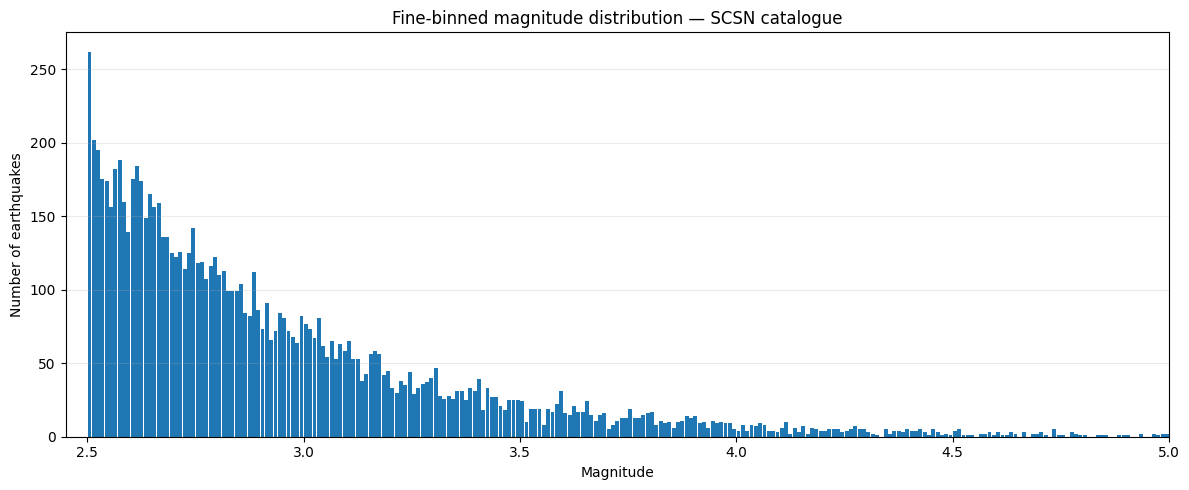

In [20]:
import numpy as np
import matplotlib.pyplot as plt

m = df["magnitude"].dropna()

# Fine 0.01 magnitude bins
bins = np.arange(
    np.floor(m.min() * 100) / 100,
    np.ceil(m.max() * 100) / 100 + 0.01,
    0.01
)

counts, edges = np.histogram(m, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(12, 5))
plt.bar(centers, counts, width=0.009, align="center")

plt.xlabel("Magnitude")
plt.ylabel("Number of earthquakes")
plt.title("Fine-binned magnitude distribution — SCSN catalogue")
plt.xlim(2.45, 5.0)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [55]:
# How many events fall on exact 0.01 and 0.10 magnitude grids?
m100 = np.round(m * 100)
m10  = np.round(m * 10)

frac_01 = np.mean(np.isclose(m * 100, m100))
frac_10 = np.mean(np.isclose(m * 10, m10))

print(f"Events on 0.01 magnitude grid: {frac_01*100:.2f}%")
print(f"Events on 0.10 magnitude grid: {frac_10*100:.2f}%")

print("\nMost frequent reported magnitudes:")
print(m.value_counts().head(20))

Events on 0.01 magnitude grid: 100.00%
Events on 0.10 magnitude grid: 11.89%

Most frequent reported magnitudes:
magnitude
2.50    262
2.51    202
2.52    195
2.57    188
2.61    184
2.56    182
2.53    175
2.60    175
2.62    174
2.54    174
2.64    165
2.58    160
2.66    159
2.55    156
2.65    156
2.63    149
2.74    142
2.59    139
2.67    136
2.68    136
Name: count, dtype: int64


All 9,417 events fall on a 0.01-magnitude grid, showing clear magnitude quantisation. The strong concentration at M2.50 also indicates accumulation near the lower catalogue limit, which should be considered when estimating Mc and b.

# **Artifact 2 — Day/night detection threshold**

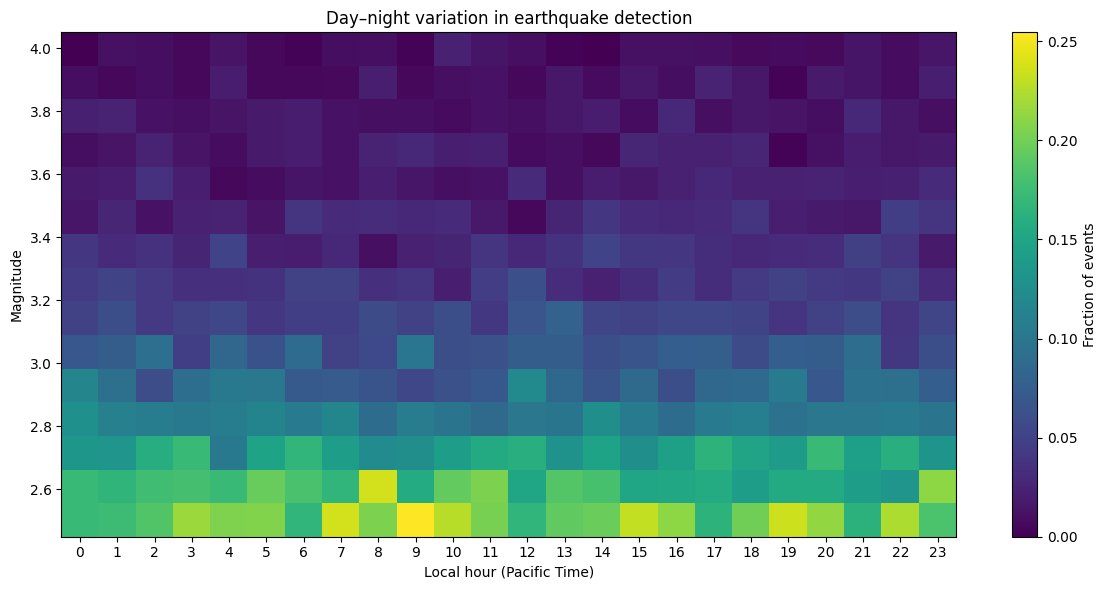

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert UTC to local California time
df["time_local"] = df["time"].dt.tz_convert("America/Los_Angeles")

# Hour of day
df["hour"] = df["time_local"].dt.hour

# Magnitude bins
mag_bins = np.arange(2.5, 4.01, 0.1)
mag_centers = (mag_bins[:-1] + mag_bins[1:]) / 2

# Count events by hour and magnitude bin
hour_mag = np.zeros((24, len(mag_centers)))

for h in range(24):
    mags = df.loc[df["hour"] == h, "magnitude"]
    hour_mag[h], _ = np.histogram(mags, bins=mag_bins)

# Normalize each hour by its total number of events
hour_mag_fraction = hour_mag / hour_mag.sum(axis=1, keepdims=True)

# Plot detection pattern
plt.figure(figsize=(12, 6))

plt.imshow(
    hour_mag_fraction.T,
    aspect="auto",
    origin="lower",
    extent=[-0.5, 23.5, 2.45, 4.05]
)

plt.colorbar(label="Fraction of events")
plt.xlabel("Local hour (Pacific Time)")
plt.ylabel("Magnitude")
plt.title("Day–night variation in earthquake detection")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [23]:
# Day vs night comparison
# Day: 07:00–19:00
# Night: 19:00–07:00

day = df[(df["hour"] >= 7) & (df["hour"] < 19)]
night = df[(df["hour"] < 7) | (df["hour"] >= 19)]

print("DAY")
print("Events:", len(day))
print("Median magnitude:", day["magnitude"].median())
print("Fraction M <= 2.7:", (day["magnitude"] <= 2.7).mean())

print("\nNIGHT")
print("Events:", len(night))
print("Median magnitude:", night["magnitude"].median())
print("Fraction M <= 2.7:", (night["magnitude"] <= 2.7).mean())

DAY
Events: 4805
Median magnitude: 2.8
Fraction M <= 2.7: 0.3793964620187305

NIGHT
Events: 4612
Median magnitude: 2.81
Fraction M <= 2.7: 0.366652211621856


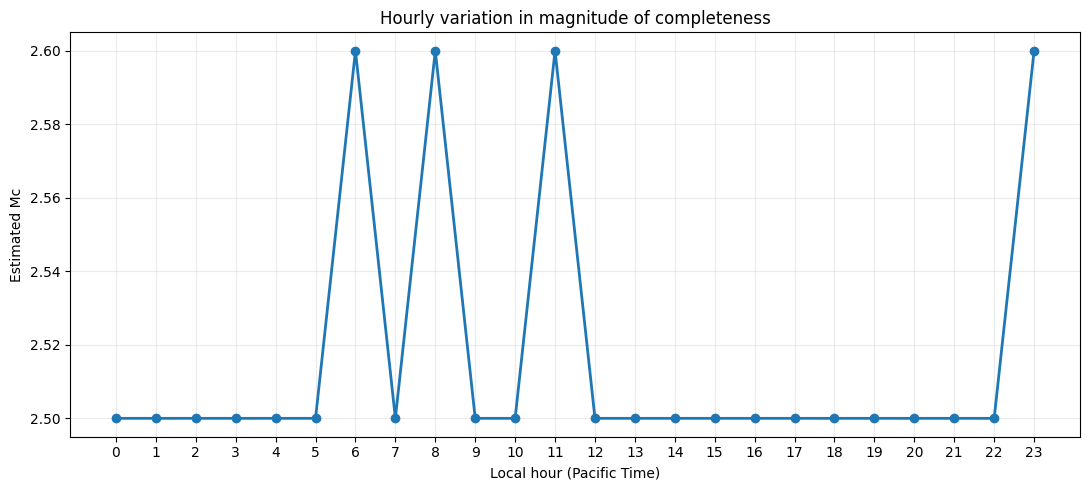

Hourly Mc:
00:00  Mc = 2.5
01:00  Mc = 2.5
02:00  Mc = 2.5
03:00  Mc = 2.5
04:00  Mc = 2.5
05:00  Mc = 2.5
06:00  Mc = 2.6
07:00  Mc = 2.5
08:00  Mc = 2.6
09:00  Mc = 2.5
10:00  Mc = 2.5
11:00  Mc = 2.6
12:00  Mc = 2.5
13:00  Mc = 2.5
14:00  Mc = 2.5
15:00  Mc = 2.5
16:00  Mc = 2.5
17:00  Mc = 2.5
18:00  Mc = 2.5
19:00  Mc = 2.5
20:00  Mc = 2.5
21:00  Mc = 2.5
22:00  Mc = 2.5
23:00  Mc = 2.6


In [24]:

# ARTIFACT 2B: HOURLY MAGNITUDE OF COMPLETENESS

import numpy as np
import matplotlib.pyplot as plt

def estimate_mc_max_curvature(mags, bin_width=0.1):
    """Estimate Mc using maximum curvature."""
    mags = np.asarray(mags)
    mags = mags[np.isfinite(mags)]

    if len(mags) < 50:
        return np.nan

    mmin = np.floor(mags.min() / bin_width) * bin_width
    mmax = np.ceil(mags.max() / bin_width) * bin_width

    bins = np.arange(mmin, mmax + bin_width, bin_width)

    counts, edges = np.histogram(mags, bins=bins)

    if len(counts) == 0 or counts.max() == 0:
        return np.nan

    # Mc = magnitude bin with maximum frequency
    idx = np.argmax(counts)

    return edges[idx]


hourly_mc = []

for h in range(24):
    mags = df.loc[df["hour"] == h, "magnitude"]
    mc = estimate_mc_max_curvature(mags)
    hourly_mc.append(mc)

# Plot
plt.figure(figsize=(11, 5))

plt.plot(
    range(24),
    hourly_mc,
    marker="o",
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel("Local hour (Pacific Time)")
plt.ylabel("Estimated Mc")
plt.title("Hourly variation in magnitude of completeness")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Hourly Mc:")
for h, mc in enumerate(hourly_mc):
    print(f"{h:02d}:00  Mc = {mc}")

The hourly Mc remains mostly 2.5–2.6, with similar small-event fractions during day and night. No systematic day–night variation in detection threshold is evident in this catalogue.

# **Artifact 3 — Network rate steps**

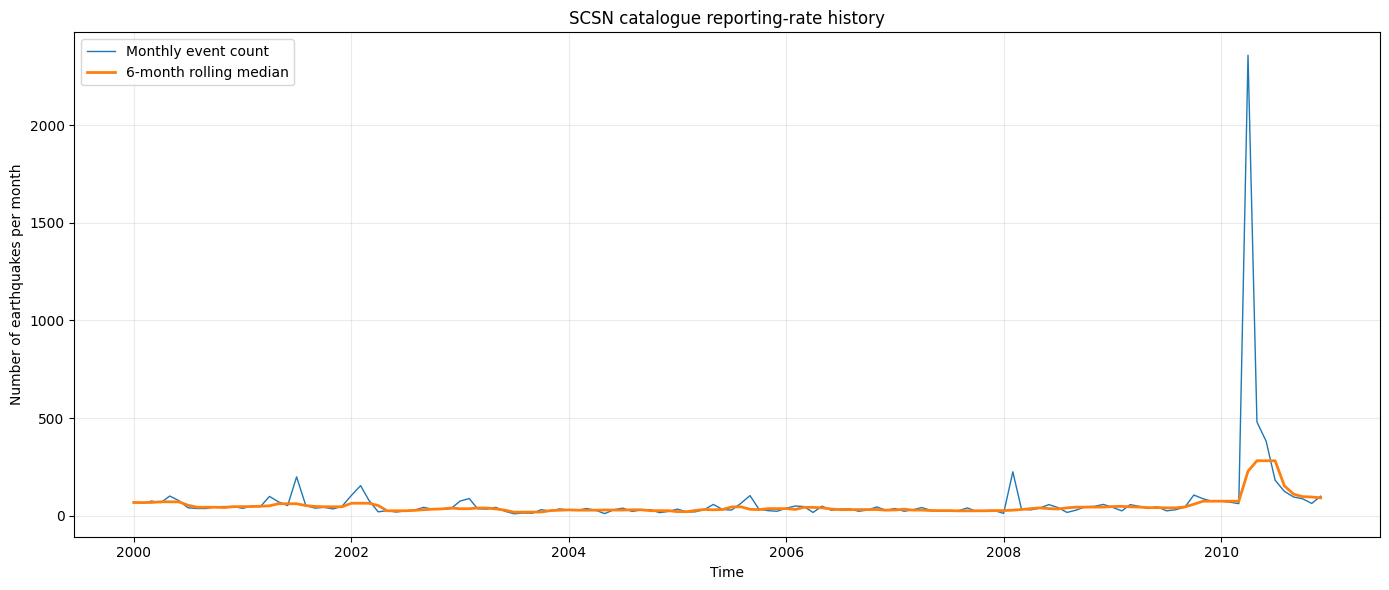

In [25]:
# Artifact:3A  EVENT-RATE STEPS THROUGH TIME

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Monthly event counts
monthly = (
    df.set_index("time")
      .resample("MS")
      .size()
)

# Rolling median to show background reporting level
rolling = monthly.rolling(6, center=True, min_periods=3).median()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly.index,
    monthly.values,
    linewidth=1,
    label="Monthly event count"
)

plt.plot(
    rolling.index,
    rolling.values,
    linewidth=2,
    label="6-month rolling median"
)

plt.xlabel("Time")
plt.ylabel("Number of earthquakes per month")
plt.title("SCSN catalogue reporting-rate history")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The monthly catalogue rate shows strong temporal variability, with pronounced increases around 2008 and 2010. These changes may reflect periods of increased seismicity and cannot alone be attributed to network changes.

In [26]:
# Identify unusually large changes between consecutive months

change = monthly.pct_change()

print("Largest month-to-month changes:")
print(
    change.abs()
          .sort_values(ascending=False)
          .head(15)
)

Largest month-to-month changes:
time
2010-04-01 00:00:00+00:00    37.016129
2008-02-01 00:00:00+00:00    17.750000
2001-07-01 00:00:00+00:00     2.826923
2006-05-01 00:00:00+00:00     1.882353
2004-06-01 00:00:00+00:00     1.818182
2009-10-01 00:00:00+00:00     1.409091
2003-10-01 00:00:00+00:00     1.384615
2009-03-01 00:00:00+00:00     1.280000
2005-08-01 00:00:00+00:00     1.172414
2001-04-01 00:00:00+00:00     1.152174
2002-01-01 00:00:00+00:00     1.122449
2003-01-01 00:00:00+00:00     1.083333
2008-03-01 00:00:00+00:00     0.848889
2005-05-01 00:00:00+00:00     0.812500
2010-05-01 00:00:00+00:00     0.796351
dtype: float64


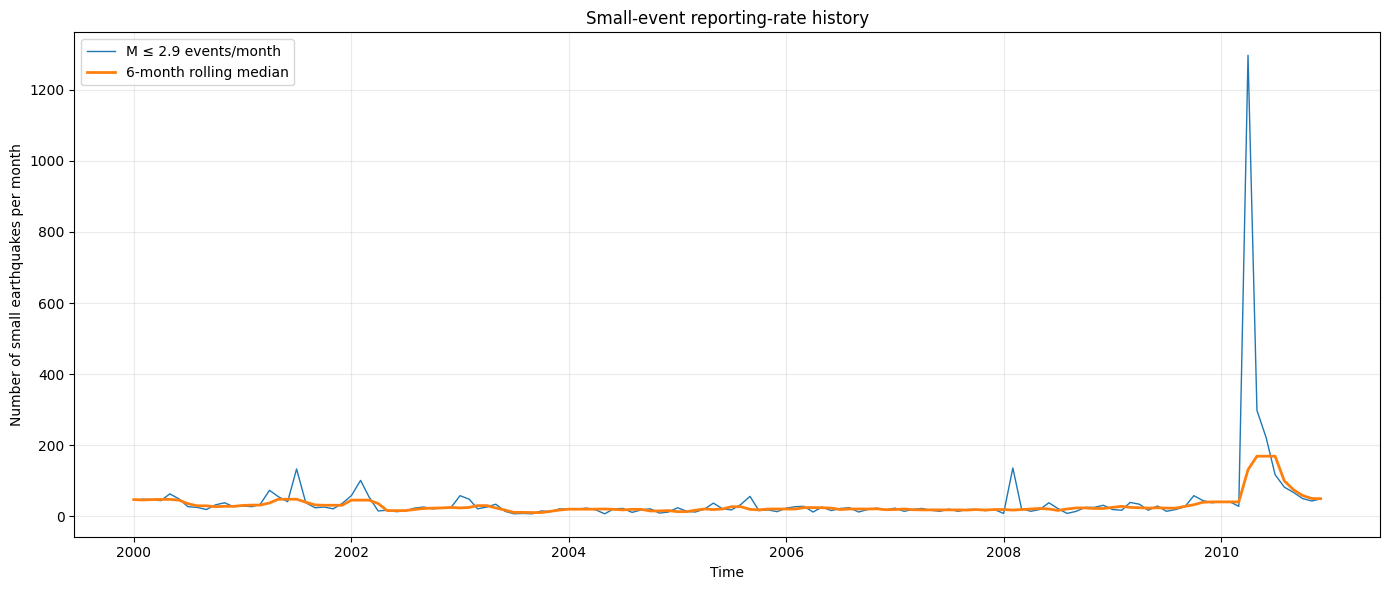

In [27]:
# ARTIFACT 3B: BACKGROUND REPORTING-RATE STEPS

# Focus on small events near the catalogue threshold
small = df[df["magnitude"] <= 2.9].copy()

monthly_small = (small.set_index("time").resample("MS").size())

# 6-month rolling median
rolling_small = monthly_small.rolling(
    6, center=True, min_periods=3
).median()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_small.index,
    monthly_small.values,
    linewidth=1,
    label="M ≤ 2.9 events/month"
)

plt.plot(
    rolling_small.index,
    rolling_small.values,
    linewidth=2,
    label="6-month rolling median"
)

plt.xlabel("Time")
plt.ylabel("Number of small earthquakes per month")
plt.title("Small-event reporting-rate history")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The M≤2.9 event rate highlights changes in the detection of smaller earthquakes. Large rate changes occur around 2008 and 2010, but without network-history metadata their cause remains indeterminate.

In [42]:
# Print months with unusually large changes in small-event rate

pct_change_small = monthly_small.pct_change()

print("Largest changes in small-event rate:")
print(
    pct_change_small.abs()
    .sort_values(ascending=False)
    .head(15)
)

Largest changes in small-event rate:
time
2010-04-01 00:00:00+00:00    45.321429
2008-02-01 00:00:00+00:00    16.000000
2001-07-01 00:00:00+00:00     2.243902
2004-06-01 00:00:00+00:00     2.000000
2003-01-01 00:00:00+00:00     1.416667
2009-03-01 00:00:00+00:00     1.294118
2006-05-01 00:00:00+00:00     1.166667
2009-10-01 00:00:00+00:00     1.148148
2001-04-01 00:00:00+00:00     1.147059
2003-10-01 00:00:00+00:00     1.142857
2008-06-01 00:00:00+00:00     1.000000
2005-01-01 00:00:00+00:00     1.000000
2005-05-01 00:00:00+00:00     0.850000
2008-03-01 00:00:00+00:00     0.838235
2005-08-01 00:00:00+00:00     0.833333
dtype: float64


# **ARTIFACT 4: AFTERSHOCK COMPLETENESS DEGRADATION**

In [45]:
# FIGURE 4 — TIME-DEPENDENT Mc AFTER THE 2010 M7.2 EVENT
# Using the ETAS-Toolkit MAXC implementation

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure project source is available
sys.path.insert(0, ".")

from src.eq_toolkit.quality.mc import maxc

# Mainshock

mainshock = df.loc[df["magnitude"].idxmax()]
t0 = mainshock["time"]

print(f"Mainshock: M{mainshock['magnitude']:.1f}")
print(f"Time: {t0}")

# 60-day aftershock sequence


after = df[
    (df["time"] > t0) &
    (df["time"] <= t0 + pd.Timedelta(days=60))
].copy()

after["days"] = (
    after["time"] - t0
).dt.total_seconds() / 86400

print(f"Aftershocks in 60 days: {len(after)}")

# Rolling MAXC

window_days = 3
step_days = 1

results = []

for start in np.arange(
    0,
    60 - window_days + 1,
    step_days
):

    end = start + window_days

    subset = after[
        (after["days"] >= start) &
        (after["days"] < end)
    ]

    if len(subset) >= 50:

        try:
            mc = maxc(
                subset["magnitude"].values,
                bin_width=0.1
            )

            results.append({
                "day": start + window_days / 2,
                "Mc": mc,
                "N": len(subset)
            })

        except Exception:
            pass

mc_df = pd.DataFrame(results)


# Print results

print("\nTime-dependent Mc:")
display(mc_df)

Mainshock: M7.2
Time: 2010-04-04 22:40:42.360000+00:00
Aftershocks in 60 days: 2843

Time-dependent Mc:


,day,Mc,N
0,1.5,2.7,1230
1,2.5,2.7,738
2,3.5,2.7,511
3,4.5,2.7,394
4,5.5,2.7,310
5,6.5,2.7,241
6,7.5,2.7,205
7,8.5,2.7,151
8,9.5,2.7,161
9,10.5,2.7,164


In [39]:
print("Mc range:")
print("Minimum Mc:", mc_df["Mc"].min())
print("Maximum Mc:", mc_df["Mc"].max())

print("\nMc frequency:")
print(mc_df["Mc"].value_counts().sort_index())

Mc range:
Minimum Mc: 2.7
Maximum Mc: 2.9000000000000004

Mc frequency:
Mc
2.7    26
2.8    10
2.9     2
Name: count, dtype: int64


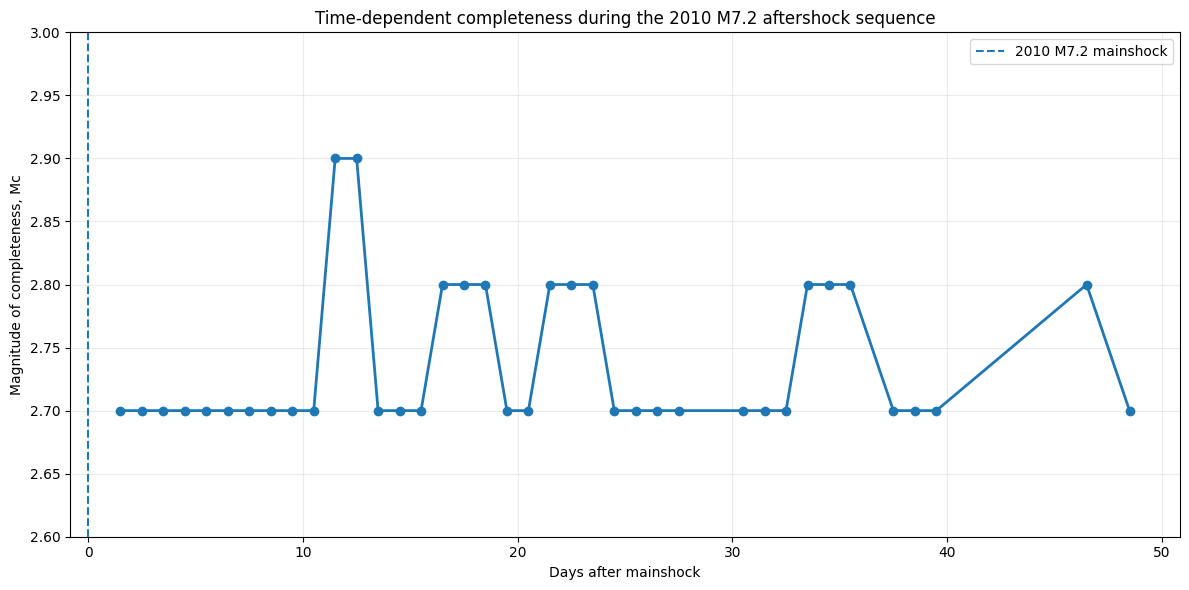

In [40]:
# FINAL CLEAN FIGURE 4

plt.figure(figsize=(12, 6))

plt.plot(
    mc_df["day"],
    mc_df["Mc"],
    marker="o",
    linewidth=2
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="2010 M7.2 mainshock"
)

plt.xlabel("Days after mainshock")
plt.ylabel("Magnitude of completeness, Mc")

plt.title(
    "Time-dependent completeness during the 2010 M7.2 aftershock sequence"
)

plt.ylim(2.6, 3.0)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "Figure_Artifact_4_Aftershock_Mc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Following the 2010 M7.2 mainshock, the estimated Mc varies between 2.7 and 2.9 during the aftershock sequence. This demonstrates that catalogue completeness is time-dependent during intense seismic activity and should not be assumed stationary.